Loading datasets...
Training Set Shape: (147613, 51)
Testing Set Shape:  (63267, 51)

Preprocessing and encoding categorical features...
Features after encoding: 64

Filtering training set for Novelty Detection...
Model will train purely on 70816 normal baseline connections.

Treinando modelo de anomalia binária (Isolation Forest)
Fazendo fit no modelo (Apenas Dados Normais)...
Predizendo no conjunto de teste misto...

--- Relatório - Detecção de Anomalia (Binária) ---
                     precision    recall  f1-score   support

         Normal (0)       0.62      0.94      0.75     30351
Ataque/Anomalia (1)       0.89      0.47      0.62     32916

           accuracy                           0.70     63267
          macro avg       0.76      0.71      0.68     63267
       weighted avg       0.76      0.70      0.68     63267



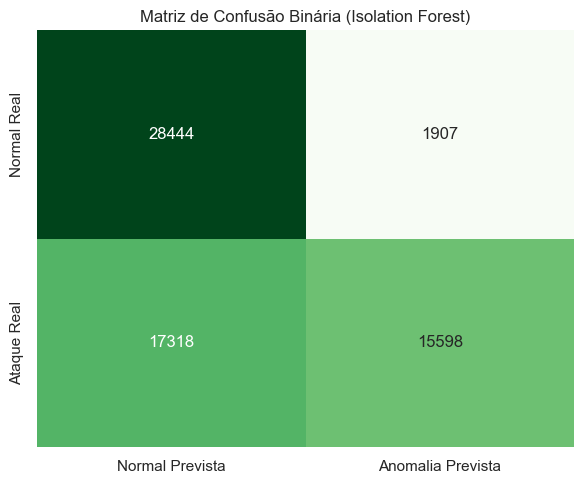


Análise de Scores de Anomalia
Score Médio para Tráfego Normal Real: -0.438 (Mais próximo de 0)
Score Médio para Ataques Reais:       -0.502 (Mais negativo)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Set visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATASETS
# ==========================================
print("Loading datasets...")
train_df = pd.read_csv("ubuntu-server_training-set.csv")
test_df = pd.read_csv("ubuntu-server_testing-set.csv")

print(f"Training Set Shape: {train_df.shape}")
print(f"Testing Set Shape:  {test_df.shape}")

# ==========================================
# 2. DATA PREPROCESSING & ENCODING
# ==========================================
print("\nPreprocessing and encoding categorical features...")

targets = ['label', 'attack_cat']
identities = ['id', 'srcip', 'sport', 'dstip', 'dsport', 'stime', 'ltime', 'ct_state_ttl']
drop_cols = targets + identities

# Separate features (X) and targets (y)
X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train_bin = train_df['label']

X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test_bin = test_df['label']

cat_cols = ['proto', 'service', 'state']

# Apply One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)

# Align Train and Test columns
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"Features after encoding: {X_train_encoded.shape[1]}")

# ==========================================
# 3. NOVELTY DETECTION PREPARATION
# ==========================================
print("\nFiltering training set for Novelty Detection...")

# Isolate ONLY the Normal traffic for training the baseline
normal_mask = (y_train_bin == 0)
X_train_normal = X_train_encoded[normal_mask]

print(f"Model will train purely on {X_train_normal.shape[0]} normal baseline connections.")

# ==========================================
# 4. ISOLATION FOREST CLASSIFICATION (BINARY)
# ==========================================
print("\n" + "="*50)
print("Treinando modelo de anomalia binária (Isolation Forest)")
print("="*50)

# Initialize Isolation Forest
# contamination='auto' allows the model to dynamically determine the threshold of what constitutes an outlier.
iforest = IsolationForest(
    n_estimators=100, 
    max_samples='auto', 
    contamination='auto', 
    random_state=42, 
    n_jobs=-1
)

print("Fazendo fit no modelo (Apenas Dados Normais)...")
iforest.fit(X_train_normal)

print("Predizendo no conjunto de teste misto...")
# Predict returns 1 for inliers (Normal) and -1 for outliers (Attacks)
y_pred_raw = iforest.predict(X_test_encoded)

# Map the Isolation Forest output back to our standard (0 = Normal, 1 = Attack)
y_pred_bin = np.where(y_pred_raw == -1, 1, 0)

# ==========================================
# 5. METRICS & EVALUATION
# ==========================================
print("\n--- Relatório - Detecção de Anomalia (Binária) ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal (0)', 'Ataque/Anomalia (1)']))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Normal Prevista', 'Anomalia Prevista'],
            yticklabels=['Normal Real', 'Ataque Real'])
plt.title('Matriz de Confusão Binária (Isolation Forest)')
plt.tight_layout()
plt.show()

# ==========================================
# 6. EXPLAINABILITY (Optional)
# ==========================================
# Isolation Forest doesn't have native "feature_importances_" like Random Forest.
# However, we can look at the average anomaly score of the test set to see the separation.
print("\n" + "="*50)
print("Análise de Scores de Anomalia")
print("="*50)

# Calculate anomaly scores (lower/more negative means more anomalous)
scores = iforest.score_samples(X_test_encoded)
test_df_scores = pd.DataFrame({'Label': y_test_bin, 'Anomaly_Score': scores})

avg_normal_score = test_df_scores[test_df_scores['Label'] == 0]['Anomaly_Score'].mean()
avg_attack_score = test_df_scores[test_df_scores['Label'] == 1]['Anomaly_Score'].mean()

print(f"Score Médio para Tráfego Normal Real: {avg_normal_score:.3f} (Mais próximo de 0)")
print(f"Score Médio para Ataques Reais:       {avg_attack_score:.3f} (Mais negativo)")